### 1. Introduction

**What is a Multi-Output Model?**

A multi-output model is a neural network that predicts **two or more different things** from the same input. Instead of having a single output layer at the end, the network branches into multiple paths, each producing its own prediction.

**Real-life Use Case: Face Analysis**

You have a dataset of human face images. Each image has two labels:
- **Age** (a continuous number, e.g., 25, 34, 42)
- **Gender** (binary: male or female)

Instead of building two separate CNNs (one for age, one for gender), you build **one CNN** that shares the feature extraction layers and then branches into two separate output layers.


**The Architecture: A Shared Backbone with Branches**

Think of this architecture as a **tree**:

```
                    ┌→ Dense (Age) → Output (Age Regression)
Input → Dense(64) → Dense(32) ┤
                    └→ Dense (Gender) → Output (Gender Classification)
```

In [1]:
from keras.models import Model
from keras.layers import Input, Dense
import numpy as np

In [2]:
# --- 1. Generate dummy data ---
# 1000 samples, 3 features each
X_train = np.random.rand(1000, 3)

# Age labels (regression target)
y_age_train = np.random.randint(18, 65, size=(1000, 1))

# Gender labels (binary classification: 0=male, 1=female)
y_gender_train = np.random.randint(0, 2, size=(1000, 1))

Step 1: Define the input layer

In [3]:
input_layer = Input(shape=(3,), name='input')

Step 2: Build shared layers

In [4]:
shared1 = Dense(64, activation='relu', name='shared1')(input_layer)
shared2 = Dense(32, activation='relu', name='shared2')(shared1)

Step 3: Create branches (each branch is a separate output)

In [5]:
# Branch 1: Predict age (regression - linear activation)
age_dense = Dense(1, activation='linear', name='age_dense')(shared2)
age_output = Dense(1, activation='linear', name='age_output')(age_dense)

In [6]:
# Branch 2: Predict gender (classification - sigmoid for binary)
gender_dense = Dense(1, activation='sigmoid', name='gender_dense')(shared2)
gender_output = Dense(1, activation='sigmoid', name='gender_output')(gender_dense)

Step 4: Create the model with multiple outputs

In [7]:
model = Model(inputs=input_layer, outputs=[age_output, gender_output])

Step 5: Compile with multiple losses

In [8]:
model.compile(
    optimizer='adam',
    loss={
        'age_output': 'mse',        # Regression loss
        'gender_output': 'binary_crossentropy'  # Classification loss
    },
    loss_weights={
        'age_output': 1.0,          # Equal importance
        'gender_output': 1.0
    },
    metrics={
        'age_output': ['mae'],
        'gender_output': ['accuracy']
    }
)

Step 6: Train with multiple targets

In [9]:

# y_train should be a list or dictionary with both targets


history = model.fit(
    X_train,
    {'age_output': y_age_train, 'gender_output': y_gender_train},
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - age_output_loss: 1859.0796 - age_output_mae: 40.8650 - gender_output_accuracy: 0.4930 - gender_output_loss: 0.7302 - loss: 1860.5763   
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 989us/step - age_output_loss: 1767.5140 - age_output_mae: 39.8002 - gender_output_accuracy: 0.4930 - gender_output_loss: 0.7160 - loss: 1775.1494
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - age_output_loss: 1562.2800 - age_output_mae: 36.9600 - gender_output_accuracy: 0.4920 - gender_output_loss: 0.6969 - loss: 1559.8344
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - age_output_loss: 1129.6417 - age_output_mae: 30.5560 - gender_output_accuracy: 0.5100 - gender_output_loss: 0.6940 - loss: 1134.8596
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - age_output_loss: 592.8859 - age_output_mae: 20.4364 - gender_output_accuracy: 0.5030 - gender_output_loss: 0.6935 - loss: 600.2523
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - age_output_los

In [10]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 3)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared1 (Dense)     │ (None, 64)        │        256 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared2 (Dense)     │ (None, 32)        │      2,080 │ shared1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_dense (Dense)   │ (None, 1)         │         33 │ shared2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_dense        │ (None, 1)         │         33 │ shared2[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │          2 │ age_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │          2 │ gender_dense[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,220 (28.21 KB)

 Trainable params: 2,406 (9.40 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,814 (18.81 KB)

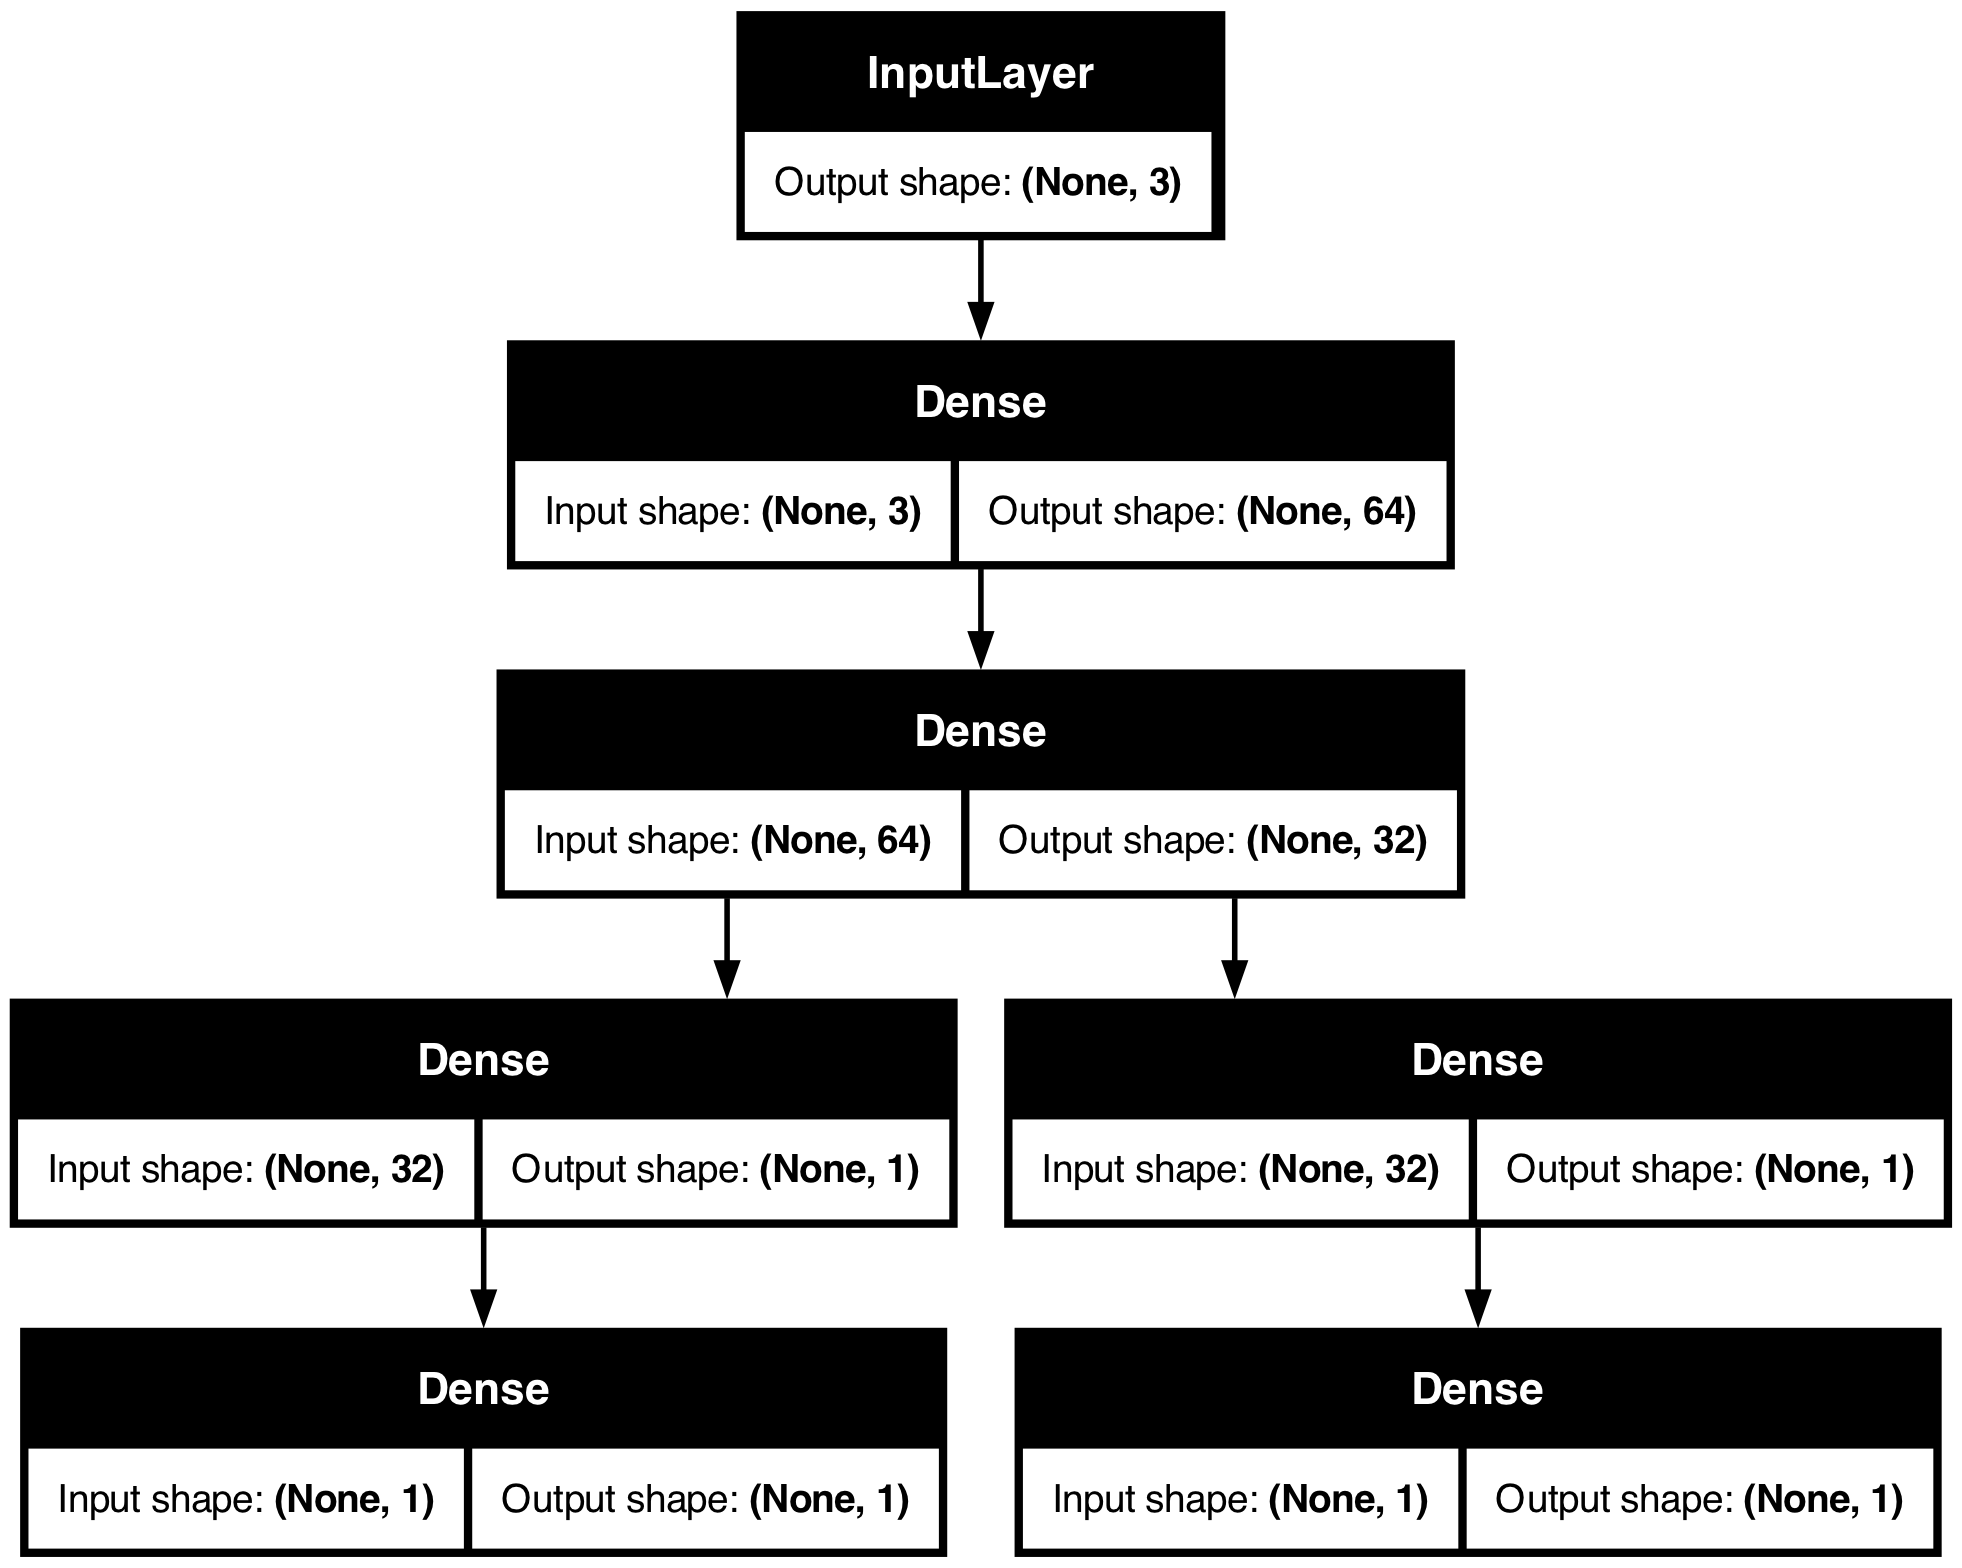

In [11]:
from keras.utils import plot_model
plot_model(model,show_shapes=True)

# --- 6. Make predictions ---

In [12]:
# New sample
X_new = np.random.rand(1, 3)
predictions = model.predict(X_new)

# predictions[0] = age prediction
# predictions[1] = gender prediction (probability)
print(f"Predicted age: {predictions[0][0][0]:.2f}")
print(f"Predicted gender probability (0=male, 1=female): {predictions[1][0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted age: 41.05
Predicted gender probability (0=male, 1=female): 0.5122
